In [ ]:
# ---
# title: "Differential Expression Analisys"
# ---
system('sudo apt-get update')
system('sudo apt-get install -y libcurl4-openssl-dev libxml2-dev libssl-dev pkg-config')

In [ ]:
# Configura um mirror fixo para evitar o erro de "unable to access index"
options(repos = c(CRAN = "https://cloud.r-project.org/"))

# Instala o BiocManager
if (!require("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}

# Instala o DESeq2 e dependências de bioinformática
# Update=FALSE e Ask=FALSE agilizam o processo no Colab
BiocManager::install(c("DESeq2", "limma", "ggplot2"), update = FALSE, ask = FALSE)

# Carrega
library(DESeq2)
library(limma)
library(ggplot2)

In [ ]:
# 1. Carregar os dados
# Dataset 1(Controle)
df_ctrl <- read.table("/content/GSE148544_Du145-sicontrol-siCDCA2.txt", header = TRUE, sep = "\t", dec = ",", check.names = FALSE)

# Dataset 2(Tumor)
df_tumor <- read.table("/content/GSM4501305_LVCaP-2_413_data.txt", header = TRUE, sep = "\t", dec = ",", check.names = FALSE)

In [ ]:
# 2. Identificar colunas de interesse
# No df_ctrl usei 'Gene_symbol' e 'Frag_count'
# No df_tumor usei a primeira coluna (genes) e 'count_sam15 siCDCA2'
rownames(df_ctrl) <- df_ctrl$Gene_symbol
rownames(df_tumor) <- df_tumor[,1]


In [ ]:
# 3. Intersecção de Genes (Lida com o número diferente de linhas)
common_genes <- intersect(rownames(df_ctrl), rownames(df_tumor))
message(paste("Genes em comum encontrados:", length(common_genes)))

In [ ]:
# 4. Construir Matriz de Contagem Única
# IMPORTANTE: Usar apenas colunas de contagem BRUTA (inteiros)

#Limpa duplicatas
df_ctrl <- df_ctrl[!duplicated(rownames(df_ctrl)), ]
df_tumor <- df_tumor[!duplicated(rownames(df_tumor)), ]
common_genes <- intersect(rownames(df_ctrl), rownames(df_tumor))

# Identifica posições das colunas de contagem
col_idx_ctrl <- grep("Frag_count", colnames(df_ctrl))[1]
col_idx_tumor <- grep("count_sam", colnames(df_tumor))[1]

# Verificação de segurança: se não achar pelo nome, força a posição
if(is.na(col_idx_ctrl)) col_idx_ctrl <- 5
if(is.na(col_idx_tumor)) col_idx_tumor <- 1

message(paste("Usando coluna", col_idx_ctrl, "do Controle e", col_idx_tumor, "do Tumor"))

# Extração segura por posição numérica [linha, coluna]
counts <- data.frame(
  Control = as.numeric(df_ctrl[common_genes, col_idx_ctrl]),
  Tumor   = as.numeric(df_tumor[common_genes, col_idx_tumor])
)
rownames(counts) <- common_genes

# Remover linhas NA
counts <- na.omit(counts)

print("Estrutura da matriz de contagens:")
print(head(counts))


In [ ]:
# 5. Configuração do Experimento
col_data <- data.frame(
  condition = factor(c("Control", "Tumor")),
  batch = factor(c("Estudo_A", "Estudo_B")), # Sinalizar origens diferentes
  row.names = colnames(counts)
)

In [ ]:
dds <- DESeqDataSetFromMatrix(countData = round(as.matrix(counts)),
                              colData = col_data,
                              design = ~ condition)

# Estimar os fatores de tamanho para normalização
dds <- estimateSizeFactors(dds)

# Como N=1, forcei a dispersão para o cálculo não travar
dispersions(dds) <- 0.1
dds <- nbinomWaldTest(dds)

In [ ]:
# 7. Extração de Resultados (LogFoldChange e P-Valor)
res <- results(dds)
res_df <- as.data.frame(res)
res_df$gene <- rownames(res_df)

# Ordenar pelos genes mais significativos
res_df <- res_df[order(res_df$pvalue), ]

# Salvar o resultado final
write.csv(res_df, "resultados_completos_DEA.csv", row.names = FALSE)
print(head(res_df))

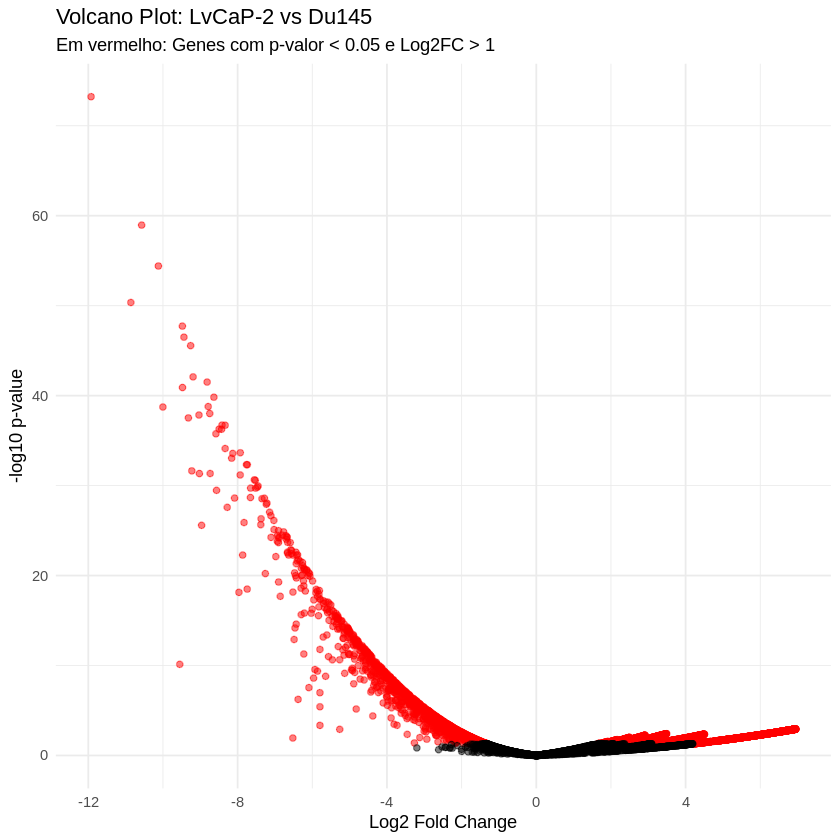

In [11]:
# Criar o gráfico
ggplot(res_df, aes(x = log2FoldChange, y = -log10(pvalue))) +
  geom_point(aes(color = (pvalue < 0.05 & abs(log2FoldChange) > 1)), alpha = 0.5) +
  scale_color_manual(values = c("black", "red")) +
  theme_minimal() +
  labs(title = "Volcano Plot: LvCaP-2 vs Du145",
       subtitle = "Em vermelho: Genes com p-valor < 0.05 e Log2FC > 1",
       x = "Log2 Fold Change", y = "-log10 p-value") +
  theme(legend.position = "none")
